
# MBTI-500 4-Axis DistilBERT (Chunked, User-Level Aggregation)

This notebook trains a **4-axis MBTI classifier** with **DistilBERT** on the **MBTI-500** dataset.

It predicts the four MBTI axes directly:

- **I / E**
- **N / S**
- **T / F**
- **J / P**

It also handles **long user text** by:

1. splitting each user's text into overlapping chunks,
2. training on chunks,
3. aggregating chunk logits back to the **user level**,
4. reconstructing the final MBTI type from the 4 predicted axes.

## Expected dataset format

Your CSV should contain at least these columns:

- `text`
- `type`

Example:

| text | type |
|---|---|
| "I enjoy abstract ideas..." | INTJ |
| "I like spontaneous group activities..." | ENFP |

---



In [ ]:


!pip install -q transformers datasets evaluate accelerate scikit-learn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [ ]:

import os
import math
import json
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda



## Configuration

Edit the values below as needed.


In [ ]:

# =========================
# CONFIG
# =========================

CSV_PATH = "/content/MBTI_500.csv"
TEXT_COL = "posts"
TYPE_COL = "type"

MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 256
STRIDE = 64

TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 4

OUTPUT_DIR = "./distilbert_mbti_axes_chunked"
BEST_MODEL_DIR = "./distilbert_mbti_axes_chunked_best"

# Set to True if you want to drop duplicate text rows
DROP_DUPLICATES = False

# If your dataset has very short noisy rows, adjust this
MIN_TEXT_LEN = 10

AXIS_NAMES = ["IE", "NS", "TF", "JP"]



## Load and validate dataset


In [ ]:

df = pd.read_csv(CSV_PATH)

required_cols = {TEXT_COL, TYPE_COL}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[[TEXT_COL, TYPE_COL]].copy()
df = df.rename(columns={TEXT_COL: "text", TYPE_COL: "type"})
df = df.dropna(subset=["text", "type"]).reset_index(drop=True)

# Clean obvious issues
df["text"] = df["text"].astype(str).str.strip()
df["type"] = df["type"].astype(str).str.strip().str.upper()

# Keep valid 4-letter MBTI types only
valid_letters = [
    set(["I", "E"]),
    set(["N", "S"]),
    set(["T", "F"]),
    set(["J", "P"]),
]

def is_valid_mbti(x):
    if not isinstance(x, str) or len(x) != 4:
        return False
    x = x.upper()
    return all(x[i] in valid_letters[i] for i in range(4))

df = df[df["type"].apply(is_valid_mbti)].copy()
df = df[df["text"].str.len() >= MIN_TEXT_LEN].copy()

if DROP_DUPLICATES:
    df = df.drop_duplicates(subset=["text", "type"]).copy()

df = df.reset_index(drop=True)
df["user_id"] = np.arange(len(df))

print("Dataset shape:", df.shape)
print(df.head())
print()
print(df["type"].value_counts().sort_index())


Dataset shape: (106067, 3)
                                                text  type  user_id
0  know intj tool use interaction people excuse a...  INTJ        0
1  rap music ehh opp yeah know valid well know fa...  INTJ        1
2  preferably p hd low except wew lad video p min...  INTJ        2
3  drink like wish could drink red wine give head...  INTJ        3
4  space program ah bad deal meing freelance max ...  INTJ        4

type
ENFJ     1534
ENFP     6167
ENTJ     2955
ENTP    11725
ESFJ      181
ESFP      360
ESTJ      482
ESTP     1986
INFJ    14963
INFP    12134
INTJ    22427
INTP    24961
ISFJ      650
ISFP      875
ISTJ     1243
ISTP     3424
Name: count, dtype: int64



## Convert MBTI type to 4-axis labels

Convention used in this notebook:

- `I = 1`, `E = 0`
- `N = 1`, `S = 0`
- `T = 1`, `F = 0`
- `J = 1`, `P = 0`


In [ ]:

def mbti_to_axes(mbti: str):
    mbti = mbti.upper()
    return [
        1.0 if mbti[0] == "I" else 0.0,
        1.0 if mbti[1] == "N" else 0.0,
        1.0 if mbti[2] == "T" else 0.0,
        1.0 if mbti[3] == "J" else 0.0,
    ]

def axes_to_mbti(bits):
    return (
        ("I" if bits[0] == 1 else "E") +
        ("N" if bits[1] == 1 else "S") +
        ("T" if bits[2] == 1 else "F") +
        ("J" if bits[3] == 1 else "P")
    )

df["labels"] = df["type"].apply(mbti_to_axes)
df[["type", "labels"]].head()



labels_array = np.array(df["labels"].tolist(), dtype=np.float32)

pos_weights = []

for i in range(4):
    pos = labels_array[:, i].sum()
    neg = len(labels_array) - pos
    weight = neg / pos
    pos_weights.append(weight)

pos_weights = torch.tensor(pos_weights, dtype=torch.float32)

print("pos_weights:", pos_weights)



pos_weights: tensor([0.3147, 0.0950, 0.5327, 1.3870])



## Train / validation / test split

Important: split **before chunking** so chunks from the same user do not leak across splits.


In [ ]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["type"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["type"],
    random_state=SEED
)

print("Train users:", len(train_df))
print("Val users  :", len(val_df))
print("Test users :", len(test_df))


Train users: 84853
Val users  : 10607
Test users : 10607



## Tokenizer and chunking

Each user's long text is split into overlapping token windows using tokenizer overflow.


In [ ]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def chunk_dataframe(input_df, tokenizer, max_length=256, stride=64):
    rows = []

    for _, row in input_df.iterrows():
        text = row["text"]
        labels = row["labels"]
        user_id = int(row["user_id"])
        mbti_type = row["type"]

        tokenized = tokenizer(
            text,
            truncation=True,
            max_length=max_length,
            stride=stride,
            return_overflowing_tokens=True,
            return_attention_mask=True,
            padding=False,
        )

        n_chunks = len(tokenized["input_ids"])

        for i in range(n_chunks):
            rows.append({
                "user_id": user_id,
                "type": mbti_type,
                "chunk_id": i,
                "input_ids": tokenized["input_ids"][i],
                "attention_mask": tokenized["attention_mask"][i],
                "labels": labels,
                "chunk_len": len(tokenized["input_ids"][i]),
            })

    return pd.DataFrame(rows)

train_chunks = chunk_dataframe(train_df, tokenizer, max_length=MAX_LENGTH, stride=STRIDE)
val_chunks   = chunk_dataframe(val_df, tokenizer, max_length=MAX_LENGTH, stride=STRIDE)
test_chunks  = chunk_dataframe(test_df, tokenizer, max_length=MAX_LENGTH, stride=STRIDE)

print("Train chunks:", len(train_chunks))
print("Val chunks  :", len(val_chunks))
print("Test chunks :", len(test_chunks))

display(train_chunks.head())


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train chunks: 255430
Val chunks  : 31914
Test chunks : 31922


,user_id,type,chunk_id,input_ids,attention_mask,labels,chunk_len
0,64196,ENTJ,0,"[101, 5310, 2404, 3696, 5310, 18442, 6013, 203...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 1.0, 1.0, 1.0]",256
1,64196,ENTJ,1,"[101, 18959, 2265, 7603, 2926, 6034, 4997, 760...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 1.0, 1.0, 1.0]",256
2,64196,ENTJ,2,"[101, 6832, 8815, 3067, 2145, 14969, 3622, 236...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0.0, 1.0, 1.0, 1.0]",218
3,31881,INTP,0,"[101, 2095, 3277, 6149, 16542, 2681, 10055, 44...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 0.0]",256
4,31881,INTP,1,"[101, 8586, 14097, 5630, 5987, 6985, 2217, 392...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 0.0]",256


In [ ]:

def summarize_chunking(chunk_df, name):
    per_user = chunk_df.groupby("user_id").size()
    print(f"{name}")
    print("-" * len(name))
    print("Users               :", chunk_df['user_id'].nunique())
    print("Chunks              :", len(chunk_df))
    print("Avg chunks / user   :", round(per_user.mean(), 2))
    print("Median chunks / user:", int(per_user.median()))
    print("Max chunks / user   :", int(per_user.max()))
    print()

summarize_chunking(train_chunks, "Train chunk summary")
summarize_chunking(val_chunks, "Validation chunk summary")
summarize_chunking(test_chunks, "Test chunk summary")


Train chunk summary
-------------------
Users               : 84853
Chunks              : 255430
Avg chunks / user   : 3.01
Median chunks / user: 3
Max chunks / user   : 7

Validation chunk summary
------------------------
Users               : 10607
Chunks              : 31914
Avg chunks / user   : 3.01
Median chunks / user: 3
Max chunks / user   : 5

Test chunk summary
------------------
Users               : 10607
Chunks              : 31922
Avg chunks / user   : 3.01
Median chunks / user: 3
Max chunks / user   : 5




## Convert chunk tables to Hugging Face datasets


In [ ]:

keep_cols = ["user_id", "type", "chunk_id", "input_ids", "attention_mask", "labels"]

train_ds = Dataset.from_pandas(train_chunks[keep_cols], preserve_index=False)
val_ds   = Dataset.from_pandas(val_chunks[keep_cols], preserve_index=False)
test_ds  = Dataset.from_pandas(test_chunks[keep_cols], preserve_index=False)

print(train_ds)
print(val_ds)
print(test_ds)


Dataset({
    features: ['user_id', 'type', 'chunk_id', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 255430
})
Dataset({
    features: ['user_id', 'type', 'chunk_id', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 31914
})
Dataset({
    features: ['user_id', 'type', 'chunk_id', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 31922
})



## Data collator


In [ ]:

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)



## Metrics and aggregation helpers

Training happens on **chunks** but evaluation happens at the **user level**.


In [ ]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def aggregate_user_predictions(logits, labels, user_ids):
    user_logits = defaultdict(list)
    user_labels = {}

    for logit, label, uid in zip(logits, labels, user_ids):
        uid = int(uid)
        user_logits[uid].append(logit)
        user_labels[uid] = np.array(label)

    agg_logits = []
    agg_labels = []
    agg_user_ids = []

    for uid in user_logits:
        mean_logit = np.mean(user_logits[uid], axis=0)
        agg_logits.append(mean_logit)
        agg_labels.append(user_labels[uid])
        agg_user_ids.append(uid)

    return np.array(agg_logits), np.array(agg_labels), np.array(agg_user_ids)

def compute_user_level_metrics_from_logits(logits, labels, user_ids, threshold=0.5):
    agg_logits, agg_labels, agg_user_ids = aggregate_user_predictions(logits, labels, user_ids)
    probs = sigmoid(agg_logits)
    preds = (probs >= threshold).astype(int)
    agg_labels = agg_labels.astype(int)

    metrics = {}

    for i, axis in enumerate(AXIS_NAMES):
        metrics[f"{axis}_accuracy"] = accuracy_score(agg_labels[:, i], preds[:, i])
        metrics[f"{axis}_f1"] = f1_score(agg_labels[:, i], preds[:, i], average="binary", zero_division=0)

    metrics["exact_match_accuracy"] = float(np.all(preds == agg_labels, axis=1).mean())

    return metrics, probs, preds, agg_labels, agg_user_ids, agg_logits



## Custom Trainer for user-level evaluation


In [ ]:
import torch.nn as nn

class WeightedUserLevelMBTITrainer(Trainer):
    def __init__(self, *args, pos_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weights = pos_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        labels = labels.to(logits.device).float()

        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=self.pos_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        eval_dataset = eval_dataset if eval_dataset is not None else self.eval_dataset

        output = self.predict(eval_dataset, metric_key_prefix=metric_key_prefix)

        logits = output.predictions
        labels = output.label_ids
        user_ids = np.array(eval_dataset["user_id"])

        metrics, _, _, _, _, _ = compute_user_level_metrics_from_logits(
            logits=logits,
            labels=labels,
            user_ids=user_ids,
            threshold=0.5
        )

        metrics = {f"{metric_key_prefix}_{k}": v for k, v in metrics.items()}
        self.log(metrics)
        return metrics


## Model


In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    problem_type="multi_label_classification"
)

model.config.id2label = {0: "IE", 1: "NS", 2: "TF", 3: "JP"}
model.config.label2id = {"IE": 0, "NS": 1, "TF": 2, "JP": 3}

print(model.__class__.__name__)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification



## Training arguments


In [ ]:

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="eval_exact_match_accuracy",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
)



## Train


In [ ]:

trainer = WeightedUserLevelMBTITrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    pos_weights=pos_weights,
)

train_output = trainer.train()
print(train_output)


Epoch,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=127716, training_loss=0.18750174337005543, metrics={'train_runtime': 9771.2552, 'train_samples_per_second': 104.564, 'train_steps_per_second': 13.071, 'total_flos': 6.767306961351014e+16, 'train_loss': 0.18750174337005543, 'epoch': 4.0})



## Evaluate on validation and test sets


In [ ]:

val_metrics = trainer.evaluate(val_ds, metric_key_prefix="val")
test_metrics = trainer.evaluate(test_ds, metric_key_prefix="test")

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

print()
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


Validation metrics:
val_IE_accuracy: 0.9417
val_IE_f1: 0.9617
val_NS_accuracy: 0.9714
val_NS_f1: 0.9843
val_TF_accuracy: 0.9502
val_TF_f1: 0.9617
val_JP_accuracy: 0.9124
val_JP_f1: 0.8960
val_exact_match_accuracy: 0.8314
epoch: 4.0000

Test metrics:
test_IE_accuracy: 0.9443
test_IE_f1: 0.9635
test_NS_accuracy: 0.9671
test_NS_f1: 0.9819
test_TF_accuracy: 0.9514
test_TF_f1: 0.9626
test_JP_accuracy: 0.9162
test_JP_f1: 0.9003
test_exact_match_accuracy: 0.8382
epoch: 4.0000



## Helper to get full user-level outputs


In [ ]:

def get_user_level_outputs(trainer, dataset, threshold=0.5):
    prediction_output = trainer.predict(dataset)
    logits = prediction_output.predictions
    labels = prediction_output.label_ids
    user_ids = np.array(dataset["user_id"])

    metrics, probs, preds, agg_labels, agg_user_ids, agg_logits = compute_user_level_metrics_from_logits(
        logits=logits,
        labels=labels,
        user_ids=user_ids,
        threshold=threshold
    )

    pred_mbti = [axes_to_mbti(row) for row in preds]
    true_mbti = [axes_to_mbti(row) for row in agg_labels.astype(int)]

    results_df = pd.DataFrame({
        "user_id": agg_user_ids,
        "true_mbti": true_mbti,
        "pred_mbti": pred_mbti,
        "true_bits": agg_labels.astype(int).tolist(),
        "pred_bits": preds.tolist(),
        "prob_I": probs[:, 0],
        "prob_N": probs[:, 1],
        "prob_T": probs[:, 2],
        "prob_J": probs[:, 3],
    })

    return metrics, results_df, agg_logits, agg_labels, probs, preds

test_user_metrics, test_results_df, test_agg_logits, test_agg_labels, test_probs, test_preds = get_user_level_outputs(
    trainer, test_ds, threshold=0.5
)

display(test_results_df.head())
print(test_user_metrics)


,user_id,true_mbti,pred_mbti,true_bits,pred_bits,prob_I,prob_N,prob_T,prob_J
0,80684,INFJ,INFJ,"[1, 1, 0, 1]","[1, 1, 0, 1]",0.995893,0.998254,0.038951,0.998485
1,7749,INTJ,INTJ,"[1, 1, 1, 1]","[1, 1, 1, 1]",0.995646,0.994639,0.997054,0.964612
2,5105,INTJ,INTJ,"[1, 1, 1, 1]","[1, 1, 1, 1]",0.967328,0.978066,0.909103,0.614818
3,35591,INTP,INTP,"[1, 1, 1, 0]","[1, 1, 1, 0]",0.979628,0.996744,0.999204,0.001875
4,39815,INTP,INTP,"[1, 1, 1, 0]","[1, 1, 1, 0]",0.982225,0.955263,0.998939,0.029386


{'IE_accuracy': 0.9442820778731027, 'IE_f1': 0.9634530950466885, 'NS_accuracy': 0.967097199962289, 'NS_f1': 0.9818748377044924, 'TF_accuracy': 0.9514471575374752, 'TF_f1': 0.9626351302328956, 'JP_accuracy': 0.9161874233996418, 'JP_f1': 0.9003474946754848, 'exact_match_accuracy': 0.8382200433675875}



## Per-axis classification reports


In [ ]:

axis_positive_labels = {
    "IE": ("E", "I"),
    "NS": ("S", "N"),
    "TF": ("F", "T"),
    "JP": ("P", "J"),
}

for i, axis in enumerate(AXIS_NAMES):
    neg_label, pos_label = axis_positive_labels[axis]
    print("=" * 70)
    print(f"{axis} classification report ({neg_label}=0, {pos_label}=1)")
    print("=" * 70)
    print(
        classification_report(
            test_agg_labels[:, i].astype(int),
            test_preds[:, i].astype(int),
            target_names=[neg_label, pos_label],
            digits=4,
            zero_division=0
        )
    )


IE classification report (E=0, I=1)
              precision    recall  f1-score   support

           E     0.8886    0.8771    0.8828      2538
           I     0.9615    0.9654    0.9635      8069

    accuracy                         0.9443     10607
   macro avg     0.9251    0.9212    0.9231     10607
weighted avg     0.9441    0.9443    0.9442     10607

NS classification report (S=0, N=1)
              precision    recall  f1-score   support

           S     0.7748    0.8750    0.8218       920
           N     0.9880    0.9758    0.9819      9687

    accuracy                         0.9671     10607
   macro avg     0.8814    0.9254    0.9019     10607
weighted avg     0.9695    0.9671    0.9680     10607

TF classification report (F=0, T=1)
              precision    recall  f1-score   support

           F     0.9234    0.9381    0.9307      3686
           T     0.9668    0.9585    0.9626      6921

    accuracy                         0.9514     10607
   macro avg     0.9


## Full reconstructed MBTI accuracy


In [ ]:

mbti_accuracy = (test_results_df["true_mbti"] == test_results_df["pred_mbti"]).mean()
print(f"Reconstructed 16-type accuracy from 4-axis outputs: {mbti_accuracy:.4f}")

print()
print("Top prediction counts:")
print(test_results_df["pred_mbti"].value_counts().head(20))


Reconstructed 16-type accuracy from 4-axis outputs: 0.8382

Top prediction counts:
pred_mbti
INTP    2484
INTJ    2235
INFJ    1506
INFP    1198
ENTP    1064
ENFP     628
ISTP     381
ENTJ     287
ESTP     234
ENFJ     166
ISTJ     126
ISFP      99
ISFJ      73
ESTJ      51
ESFP      42
ESFJ      33
Name: count, dtype: int64



## Confusion matrices for each axis


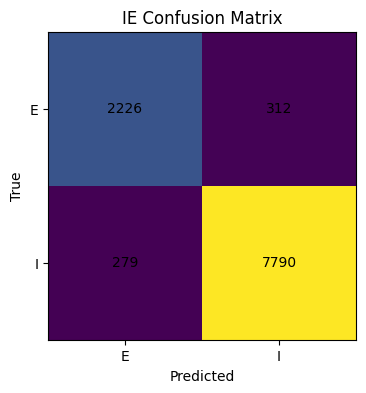

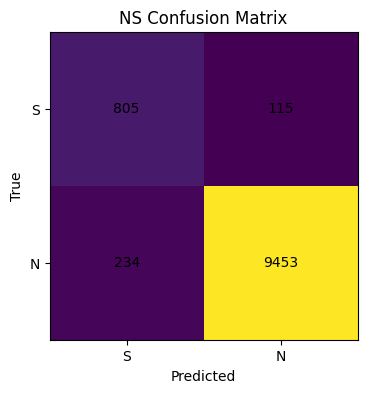

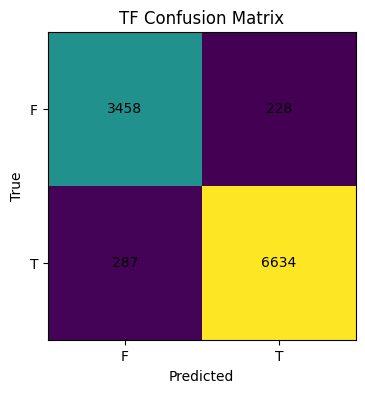

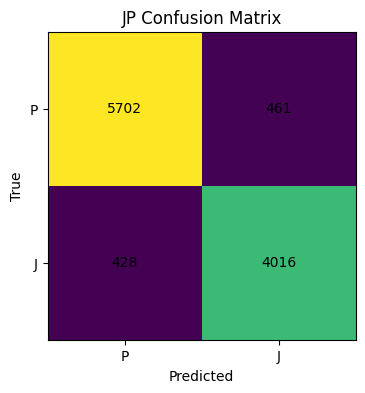

In [ ]:

for i, axis in enumerate(AXIS_NAMES):
    neg_label, pos_label = axis_positive_labels[axis]
    cm = confusion_matrix(
        test_agg_labels[:, i].astype(int),
        test_preds[:, i].astype(int)
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(f"{axis} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1], [neg_label, pos_label])
    ax.set_yticks([0, 1], [neg_label, pos_label])

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center")

    plt.show()



## Training curves


,loss,grad_norm,learning_rate,epoch,step,eval_IE_accuracy,eval_IE_f1,eval_NS_accuracy,eval_NS_f1,eval_TF_accuracy,...,val_exact_match_accuracy,test_IE_accuracy,test_IE_f1,test_NS_accuracy,test_NS_f1,test_TF_accuracy,test_TF_f1,test_JP_accuracy,test_JP_f1,test_exact_match_accuracy
6,0.132507,0.864384,1.565975e-10,4.0,127716,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,127716,0.941737,0.961705,0.971434,0.984256,0.950222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,127716,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,4.0,127716,NaN,NaN,NaN,NaN,NaN,...,0.831432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,4.0,127716,NaN,NaN,NaN,NaN,NaN,...,NaN,0.944282,0.963453,0.967097,0.981875,0.951447,0.962635,0.916187,0.900347,0.83822


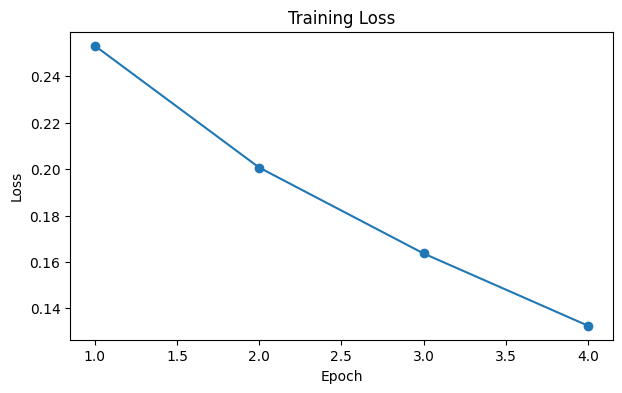

,epoch,eval_IE_accuracy,eval_IE_f1,eval_NS_accuracy,eval_NS_f1,eval_TF_accuracy,eval_TF_f1,eval_JP_accuracy,eval_JP_f1,eval_exact_match_accuracy,val_IE_accuracy,val_IE_f1,val_NS_accuracy,val_NS_f1,val_TF_accuracy,val_TF_f1,val_JP_accuracy,val_JP_f1,val_exact_match_accuracy
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,0.927689,0.951837,0.951259,0.972771,0.946073,0.958144,0.910625,0.894573,0.804280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,0.924295,0.948876,0.966060,0.981213,0.952578,0.963271,0.918544,0.900644,0.822381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,0.939945,0.960245,0.955784,0.975338,0.952201,0.963248,0.912793,0.899117,0.820119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.0,0.941737,0.961705,0.971434,0.984256,0.950222,0.961717,0.912416,0.896027,0.831432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.941737,0.961705,0.971434,0.984256,0.950222,0.961717,0.912416,0.896027,0.831432


In [ ]:

log_history = trainer.state.log_history
history_df = pd.DataFrame(log_history)

display(history_df.tail())

if "loss" in history_df.columns:
    train_loss_df = history_df.dropna(subset=["loss"]).copy()
    plt.figure(figsize=(7, 4))
    plt.plot(train_loss_df["epoch"], train_loss_df["loss"], marker="o")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

metric_cols = [c for c in history_df.columns if c.startswith("eval_") or c.startswith("val_")]
display(history_df[["epoch"] + [c for c in metric_cols if c in history_df.columns]].dropna(how="all"))



## Save the best model and tokenizer


In [ ]:

trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

print("Saved model to:", BEST_MODEL_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./distilbert_mbti_axes_chunked_best


In [ ]:
!zip -r distilbert_mbti_axes_chunked_best.zip ./distilbert_mbti_axes_chunked_best

  adding: distilbert_mbti_axes_chunked_best/ (stored 0%)
  adding: distilbert_mbti_axes_chunked_best/training_args.bin (deflated 53%)
  adding: distilbert_mbti_axes_chunked_best/model.safetensors (deflated 8%)
  adding: distilbert_mbti_axes_chunked_best/tokenizer.json (deflated 71%)
  adding: distilbert_mbti_axes_chunked_best/config.json (deflated 50%)
  adding: distilbert_mbti_axes_chunked_best/tokenizer_config.json (deflated 42%)



## Inference: predict one long text with chunk aggregation


In [ ]:

def predict_mbti_chunked(
    text,
    model,
    tokenizer,
    max_length=256,
    stride=64,
    threshold=0.5,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        return_attention_mask=True,
        padding=False,
    )

    input_ids_list = tokenized["input_ids"]
    attention_mask_list = tokenized["attention_mask"]

    chunk_logits = []

    with torch.no_grad():
        for ids, mask in zip(input_ids_list, attention_mask_list):
            batch = {
                "input_ids": torch.tensor([ids], dtype=torch.long, device=device),
                "attention_mask": torch.tensor([mask], dtype=torch.long, device=device),
            }
            outputs = model(**batch)
            chunk_logits.append(outputs.logits.detach().cpu().numpy()[0])

    chunk_logits = np.array(chunk_logits)
    mean_logits = np.mean(chunk_logits, axis=0)
    probs = sigmoid(mean_logits)
    preds = (probs >= threshold).astype(int)
    mbti = axes_to_mbti(preds)

    return {
        "mbti": mbti,
        "binary_outputs": preds.tolist(),
        "probabilities": {
            "I": float(probs[0]),
            "N": float(probs[1]),
            "T": float(probs[2]),
            "J": float(probs[3]),
        },
        "num_chunks": len(chunk_logits),
        "mean_logits": mean_logits.tolist(),
    }


In [ ]:

sample_text = '''
I love exploring abstract ideas and complex theories. I prefer spending time
alone reading or thinking rather than going to parties. I often come up with
unconventional solutions to problems and enjoy debating philosophical questions.
I tend to plan things carefully and make lists before starting any project.
'''

sample_result = predict_mbti_chunked(
    text=sample_text,
    model=trainer.model,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
    stride=STRIDE,
    threshold=0.5,
)

sample_result


{'mbti': 'ISTJ',
 'binary_outputs': [1, 0, 1, 1],
 'probabilities': {'I': 0.7527403235435486,
  'N': 0.33545970916748047,
  'T': 0.6710395812988281,
  'J': 0.5962568521499634},
 'num_chunks': 1,
 'mean_logits': [1.11328125, -0.68359375, 0.712890625, 0.389892578125]}


## Optional: save user-level predictions to CSV


In [ ]:

test_results_df.to_csv("test_user_level_predictions.csv", index=False)
print("Saved test_user_level_predictions.csv")


Saved test_user_level_predictions.csv


In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
print(df["type"].value_counts())

type
INTP    24961
INTJ    22427
INFJ    14963
INFP    12134
ENTP    11725
ENFP     6167
ISTP     3424
ENTJ     2955
ESTP     1986
ENFJ     1534
ISTJ     1243
ISFP      875
ISFJ      650
ESTJ      482
ESFP      360
ESFJ      181
Name: count, dtype: int64


In [ ]:
from huggingface_hub import create_repo, upload_folder

repo_id = "Win02/distilbert-mbti-axes-v2"

create_repo(repo_id, repo_type="model", exist_ok=True)

upload_folder(
    repo_id=repo_id,
    folder_path="/content/distilbert_mbti_axes_chunked_best",
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ed_best/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

  ...ed_best/model.safetensors:   0%|          |  575kB /  268MB            

CommitInfo(commit_url='https://huggingface.co/Win02/distilbert-mbti-axes-v2/commit/b6a03faf77ed76bd9c4da021013360bd7da2a7ea', commit_message='Upload folder using huggingface_hub', commit_description='', oid='b6a03faf77ed76bd9c4da021013360bd7da2a7ea', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Win02/distilbert-mbti-axes-v2', endpoint='https://huggingface.co', repo_type='model', repo_id='Win02/distilbert-mbti-axes-v2'), pr_revision=None, pr_num=None)


## Notes

- This notebook trains on **chunks** but evaluates on the **user level**.
- `exact_match_accuracy` means all 4 axis predictions must be correct for a user.
- Reconstructed MBTI type is derived from the 4 predicted axes.
- If you run out of memory, reduce:
  - `TRAIN_BATCH_SIZE`
  - `MAX_LENGTH`
- If training is slow, reduce:
  - `NUM_EPOCHS`
  - `MAX_LENGTH`
  - dataset size for a quick test run

---
